<>:75: SyntaxWarning: invalid escape sequence '\L'
<>:80: SyntaxWarning: invalid escape sequence '\g'
<>:75: SyntaxWarning: invalid escape sequence '\L'
<>:80: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_11633/459591846.py:75: SyntaxWarning: invalid escape sequence '\L'
  ax.text(0.0006, h_max_val/2, 'Case ii: Bounded Interval\nPooling Optimal in $[\Lambda_1^*, \Lambda_2^*]$',
/tmp/ipykernel_11633/459591846.py:80: SyntaxWarning: invalid escape sequence '\g'
  ax.text(0.0005, h_max_val + 1.5, f'Case iii: $h \geq h_{{max}}$ (~{h_max_val:.1f})\nStrictly Dedicated',


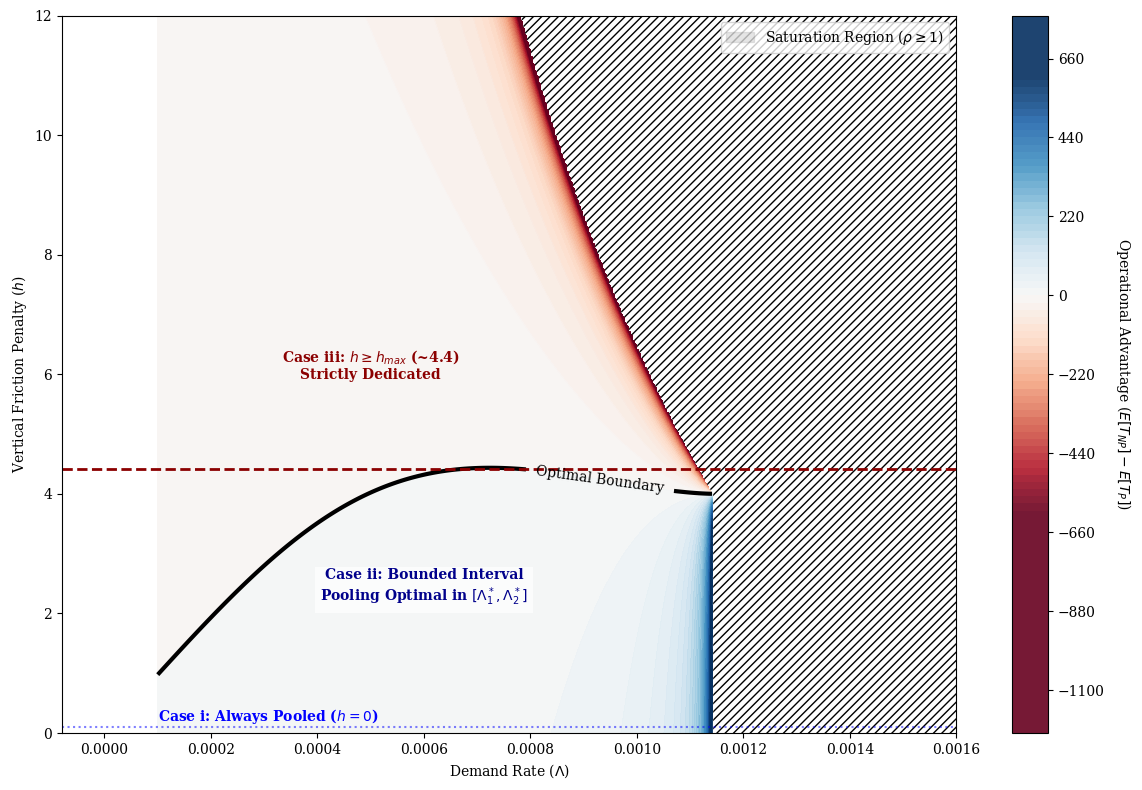

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


plt.rcParams.update({'font.size': 10, 'font.family': 'serif'})

def get_performance_results(Lambda, R, v, p0, h):
    lam_total = Lambda * (R**2)

    # 1. Dedicated (Non-Pooling - NP)
    tau_NP = (4 * R) / (3 * v)
    rho_NP = lam_total * max(p0, 1 - p0) * tau_NP

    # 2. Pooled (P)
    tau_P = (4 * R + 3 * h) / (3 * v)
    rho_P = (lam_total * tau_P) / 2.0

    # Define Stability (Saturation points)
    is_unstable = (rho_NP >= 0.99 or rho_P >= 0.99)

    if is_unstable:
        return np.nan, True

    # Expected Response Times
    t_np = p0 * (tau_NP / (1 - lam_total * p0 * tau_NP)) + \
           (1 - p0) * (tau_NP / (1 - lam_total * (1 - p0) * tau_NP))
    t_p = tau_P / (1 - rho_P**2)

    return (t_np - t_p), False

# Parameters
R_val, v_val, p0_val = 10.0, 1.0, 0.65
lambdas = np.linspace(0.0001, 0.0016, 400)
h_penalties = np.linspace(0, 12, 400)

L, H = np.meshgrid(lambdas, h_penalties)
Z = np.zeros_like(L)
Saturation_Mask = np.zeros_like(L, dtype=bool)

for i in range(len(h_penalties)):
    for j in range(len(lambdas)):
        val, unstable = get_performance_results(lambdas[j], R_val, v_val, p0_val, h_penalties[i])
        Z[i, j] = val
        Saturation_Mask[i, j] = unstable

# Identify h_max for Case iii boundary
# h_max is the highest h where any pooling advantage (Z > 0) exists
advantage_indices = np.where(np.nan_to_num(Z) > 0)
h_max_val = h_penalties[advantage_indices[0].max()] if len(advantage_indices[0]) > 0 else 0

fig, ax = plt.subplots(figsize=(12, 8))

# Diverging color map centered at zero
limit = np.nanmax(np.abs(np.nan_to_num(Z))) * 0.5
norm = TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)
cp = ax.contourf(L, H, Z, levels=100, cmap='RdBu', norm=norm, alpha=0.9)
cbar = fig.colorbar(cp)
cbar.set_label('Operational Advantage ($E[T_{NP}] - E[T_P]$)', rotation=270, labelpad=20)

# Optimal Boundary (Black line defining the Interval [Lambda1, Lambda2])
CS = ax.contour(L, H, Z, levels=[0], colors='black', linewidths=3)
ax.clabel(CS, inline=True, fmt='Optimal Boundary', fontsize=10)

# Saturation Points (Hatched Region)
ax.contourf(L, H, Saturation_Mask, levels=[0.5, 1], colors='none', hatches=['////'], alpha=0)
ax.fill_between([0], [0], color='grey', alpha=0.2, hatch='////', label=r'Saturation Region ($\rho \geq 1$)')

# Explicitly marking the 3 Regimes
# Case i: Baseline
ax.axhline(0.1, color='blue', linestyle=':', alpha=0.5)
ax.text(0.0001, 0.2, 'Case i: Always Pooled ($h=0$)', color='blue', fontweight='bold')

# Case ii: The Dome
ax.text(0.0006, h_max_val/2, 'Case ii: Bounded Interval\nPooling Optimal in $[\Lambda_1^*, \Lambda_2^*]$',
        color='darkblue', fontweight='bold', ha='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# Case iii: Above h_max
ax.axhline(h_max_val, color='darkred', linestyle='--', linewidth=2)
ax.text(0.0005, h_max_val + 1.5, f'Case iii: $h \geq h_{{max}}$ (~{h_max_val:.1f})\nStrictly Dedicated',
        color='darkred', fontweight='bold', ha='center')

ax.set_xlabel(r'Demand Rate ($\Lambda$)')
ax.set_ylabel(r'Vertical Friction Penalty ($h$)')
#ax.set_title('Regime Map: Architecture Optimality and System Stability')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/fig33_revised.pdf'

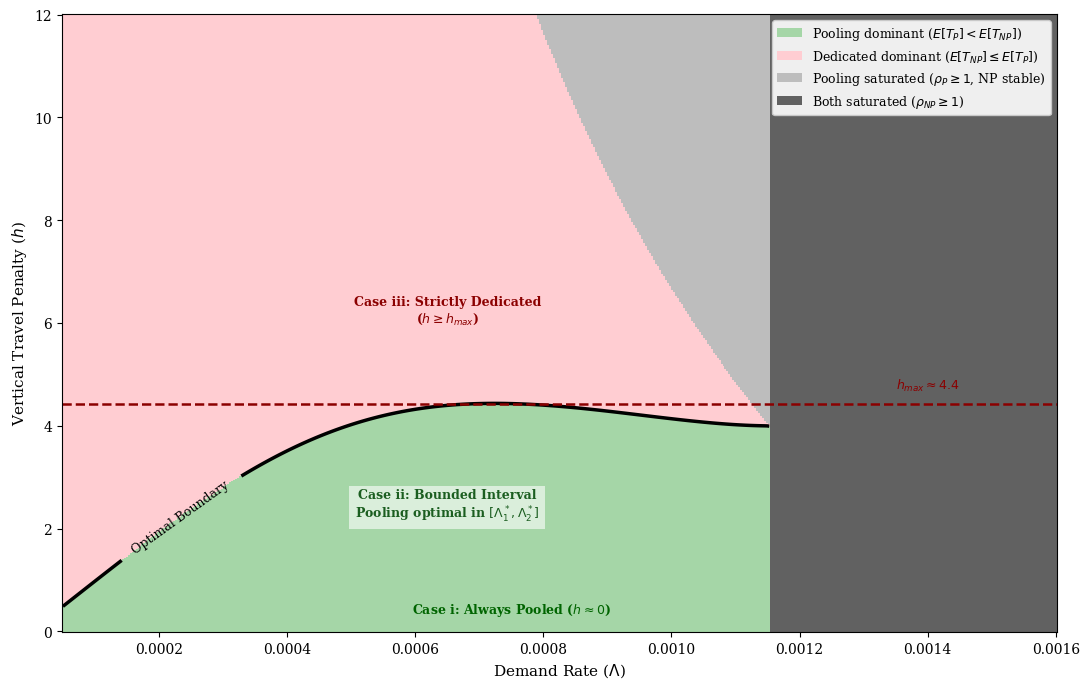

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

plt.rcParams.update({'font.size': 10, 'font.family': 'serif'})

# ── Parameters ────────────────────────────────────────────────────────────────
R, v, p0 = 10.0, 1.0, 0.65

# Service rates (analytical, consistent with Chapter 3 / Section 3.4)
# mu_NP = 3v / (4R)  — each dedicated server
# mu_P  = 3v / (4R + 3h)  — each pooled server

def service_rates(h):
    mu_NP = (3 * v) / (4 * R)
    mu_P  = (3 * v) / (4 * R + 3 * h)
    return mu_NP, mu_P

def compute_region(Lambda, h):
    """
    Returns:
      'both_sat'  : both NP and P are saturated (rho >= 1)
      'p_sat'     : only P is saturated; NP still stable
      'np_dom'    : both stable, NP has lower E[T]  (Z <= 0)
      'p_dom'     : both stable, P  has lower E[T]  (Z > 0)
    """
    mu_NP, mu_P = service_rates(h)
    lam = Lambda * R**2

    # Per-floor arrival rates under asymmetric demand
    lam_NP_floor1 = lam * p0
    lam_NP_floor2 = lam * (1 - p0)
    lam_P_total   = lam          # both servers share total load

    rho_NP = max(lam_NP_floor1 / mu_NP, lam_NP_floor2 / mu_NP)
    rho_P  = lam_P_total / (2 * mu_P)   # M/M/2: rho = lambda / (2*mu)

    np_sat   = rho_NP >= 1.0
    p_sat    = rho_P  >= 1.0

    if np_sat:
        return 'both_sat'     # NP saturates after P, so if NP is sat so is P
    if p_sat:
        return 'p_sat'        # P saturated, NP still running

    # Both stable — compute analytical response times
    # NP: weighted average of two M/M/1 queues
    E_T_NP = (p0       * (1.0 / (mu_NP - lam_NP_floor1)) +
              (1 - p0) * (1.0 / (mu_NP - lam_NP_floor2)))

    # P: M/M/2 queue
    E_T_P = (1.0 / mu_P) * (1.0 / (1.0 - rho_P**2))

    if E_T_P < E_T_NP:
        return 'p_dom'
    else:
        return 'np_dom'

# ── Grid ──────────────────────────────────────────────────────────────────────
lambdas    = np.linspace(0.00005, 0.0016, 500)
h_vals     = np.linspace(0.0,    12.0,   500)
L, H       = np.meshgrid(lambdas, h_vals)

# Region codes: 0=np_dom, 1=p_dom, 2=p_sat, 3=both_sat
REGION = np.zeros_like(L, dtype=int)
for i in range(len(h_vals)):
    for j in range(len(lambdas)):
        r = compute_region(lambdas[j], h_vals[i])
        if   r == 'p_dom':    REGION[i, j] = 1
        elif r == 'p_sat':    REGION[i, j] = 2
        elif r == 'both_sat': REGION[i, j] = 3

# ── Color map — four distinct regions ─────────────────────────────────────────
# 0: NP dominant  → light red/pink  (Travel Penalty Zone)
# 1: P dominant   → light green     (Optimal Pooling Zone)
# 2: P saturated  → light grey      (Pooling Saturation)
# 3: Both sat     → dark grey       (Full Saturation)
cmap = ListedColormap(['#FFCDD2', '#A5D6A7', '#BDBDBD', '#616161'])

fig, ax = plt.subplots(figsize=(11, 7))
img = ax.pcolormesh(L, H, REGION, cmap=cmap, vmin=0, vmax=3, shading='auto')

# ── Optimal boundary: contour where E[T_NP] = E[T_P], within stable region ───
# Compute Z = E[T_NP] - E[T_P] on the stable sub-grid only
Z = np.full_like(L, np.nan)
for i in range(len(h_vals)):
    for j in range(len(lambdas)):
        if REGION[i, j] <= 1:   # both stable
            mu_NP, mu_P = service_rates(h_vals[i])
            lam = lambdas[j] * R**2
            lam1 = lam * p0
            lam2 = lam * (1 - p0)
            rho_P = lam / (2 * mu_P)
            E_NP = (p0 * (1/(mu_NP - lam1)) + (1-p0) * (1/(mu_NP - lam2)))
            E_P  = (1/mu_P) * (1/(1 - rho_P**2))
            Z[i, j] = E_NP - E_P

CS = ax.contour(L, H, Z, levels=[0], colors='black', linewidths=2.5)
ax.clabel(CS, inline=True, fmt='Optimal Boundary', fontsize=9)

# ── h_max line ────────────────────────────────────────────────────────────────
# h_max: highest h where the P-dominant region exists
p_dom_rows = np.where(np.any(REGION == 1, axis=1))[0]
if len(p_dom_rows):
    h_max_val = h_vals[p_dom_rows.max()]
    ax.axhline(h_max_val, color='darkred', linestyle='--', linewidth=1.8,
               label=rf'$h_{{max}} \approx {h_max_val:.1f}$')
    ax.text(0.00135, h_max_val + 0.3,
            rf'$h_{{max}} \approx {h_max_val:.1f}$',
            color='darkred', fontsize=9)

# ── Case annotations ──────────────────────────────────────────────────────────
ax.text(0.00075, 0.35, 'Case i: Always Pooled ($h \\approx 0$)',
        color='darkgreen', fontweight='bold', ha='center', fontsize=9)
ax.text(0.00065, h_max_val / 2,
        'Case ii: Bounded Interval\n' + r'Pooling optimal in $[\Lambda_1^*, \Lambda_2^*]$',
        color='#1B5E20', fontweight='bold', ha='center', fontsize=9,
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
ax.text(0.00065, h_max_val + 1.6,
        'Case iii: Strictly Dedicated\n' + r'($h \geq h_{max}$)',
        color='darkred', fontweight='bold', ha='center', fontsize=9)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    Patch(facecolor='#A5D6A7', label=r'Pooling dominant ($E[T_P] < E[T_{NP}]$)'),
    Patch(facecolor='#FFCDD2', label=r'Dedicated dominant ($E[T_{NP}] \leq E[T_P]$)'),
    Patch(facecolor='#BDBDBD', label=r'Pooling saturated ($\rho_P \geq 1$, NP stable)'),
    Patch(facecolor='#616161', label=r'Both saturated ($\rho_{NP} \geq 1$)'),
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True,
          framealpha=0.9, fontsize=9)

ax.set_xlabel(r'Demand Rate ($\Lambda$)', fontsize=11)
ax.set_ylabel(r'Vertical Travel Penalty ($h$)', fontsize=11)
plt.tight_layout()
plt.savefig('/home/claude/fig33_revised.pdf', bbox_inches='tight')
plt.savefig('/home/claude/fig33_revised.png', dpi=300, bbox_inches='tight')
print(f"Done. h_max ≈ {h_max_val:.2f}")